In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.integrate as scin

In [7]:
datos = np.loadtxt("datos.dat")

dominio_t = datos[:,1]
y_t = datos[:,2]

In [42]:
def solucion(t):
    return 0.5*(t*np.sqrt(1-t**2)+np.arcsin(t))+1

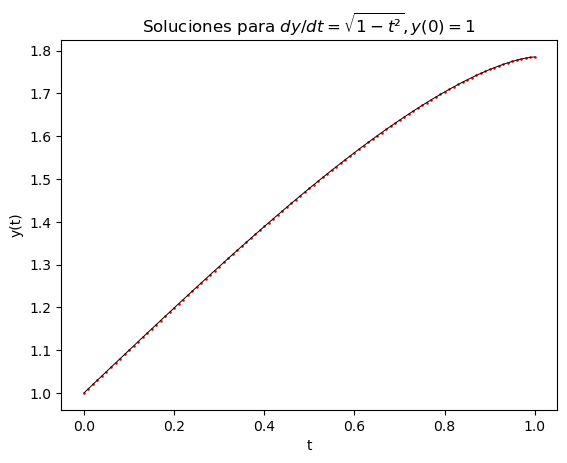

In [48]:
def f(t, y):
    if t**2 <= 1.0:
        return np.sqrt(1.0 - t**2)
    else:
        return 0.0

y0 = [1.0]

t0 = 0.0
t_max = 1.0
t_span = (t0, t_max)

solution = scin.solve_ivp(f, t_span, y0, method='RK45', dense_output=True)

t_vals = np.linspace(t0, t_max, 101)
y_vals = solution.sol(t_vals)[0]

#plt.scatter(t_vals, y_vals, color='r', s=0.8, label='y(t) con Python')
plt.scatter(dominio_t,y_t, color='r', s=0.8,label='y(t) con Fortran')
plt.plot(t_vals,solucion(t_vals),color='k', linewidth=0.7)
plt.xlabel('t')
plt.ylabel('y(t)')
plt.title("Soluciones para $dy/dt = \sqrt{1 - t²}, y(0) = 1$")
plt.legend
plt.show()